# Prácticas SEPER

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parámetros del Inversor

In [13]:
S_nom_real = 1  # MVA
U_nom_real = 690  # V, Tensión de Red RMS-Línea
U_dc_real = 1300  # V, Tensión de bus DC

X_inv = 0.2  # pu, Reactancia del inversor
R_inv = 0.03  # pu, Resistencia de la bobina del inversor
C = 0.04  # pu, Condensador del filtro
R_c = 0.15  # pu, Resistencia de amortiguamiento

f_s = 3000  # Hz, Frecuencia de conmutación
f_m = 6000  # Hz, Frecuencia de muestreo

RED = {
    "Fuerte": {
        "SCR": 10.0, "X/R": 10.0
    },
    "Débil": {
        "SCR": 2.0, "X/R": 10.0
    }
}

### Parámetros en por unidad

In [14]:
S_nom = 1  # pu
U_nom = 1  # pu
U_dc = U_dc_real / U_nom_real

## Sesión 1: Diseño del lazo de potencia activa activa para seguiiento de referencia con controlador basado en la swing equation

### Punto de Operación

In [15]:
U_g = 1
P_g = 0.5
Q_g = 0

#### Test ecuaciones ejemplos de clases

In [16]:
X_t = 0.4
U_g = 1.
P_g = 0.4
Q_g = 0.3

I = get_current_magnitude(U_g, P_g, Q_g)
phi = get_current_angle(U_g, P_g, Q_g)
cosphi = get_power_factor(U_g, P_g, Q_g)

display(f"I = {I:.4f} pu")
display(f"phi = {phi:.4f} rad = {np.degrees(phi):.4f}°")
display(f"cosphi = {cosphi:.4f}")

E, delta = get_E_delta(U_g, X_t, I, phi)
display(f"E = {E:.4f} pu")
display(f"delta = {delta:.4f} rad = {np.degrees(delta):.4f}°")

'I = 0.5000 pu'

'phi = 0.6435 rad = 36.8699°'

'cosphi = 0.8000'

'E = 1.1314 pu'

'delta = 0.1419 rad = 8.1301°'

#### Frente a una red fuerte

In [17]:
Z_g = 1 / RED["Fuerte"]["SCR"]
X_g = Z_g * (RED["Fuerte"]["X/R"]) / np.sqrt(1 + (RED["Fuerte"]["X/R"])**2)

X_t = X_inv + X_g

display("==== RED FUERTE ====")
display(f"Z_g = {Z_g:.4f} pu")
display(f"X_g = {X_g:.4f} pu")
display(f"X_t = {X_t:.4f} pu")

I = get_current_magnitude(P_g, Q_g, U_g)
phi = get_current_angle(P_g, Q_g, U_g)
cosphi = get_power_factor(P_g, Q_g, U_g)

display(f"I = {I:.4f} pu")
display(f"phi = {phi:.4f} rad = {np.degrees(phi):.4f}°")
display(f"cosphi = {cosphi:.4f}")

E, delta = get_E_delta(U_g, X_t, I, phi)
display(f"E = {E:.4f} pu")
display(f"delta = {delta:.4f} rad = {np.degrees(delta):.4f}°")

'==== RED FUERTE ===='

'Z_g = 0.1000 pu'

'X_g = 0.0995 pu'

'X_t = 0.2995 pu'

'I = 2.6101 pu'

'phi = 1.2793 rad = 73.3008°'

'cosphi = 0.2873'

'E = 1.7631 pu'

'delta = 0.1278 rad = 7.3196°'

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Diagrama Fasorial Red Fuerte'}, xlabel='Real', ylabel='Imaginario'>)

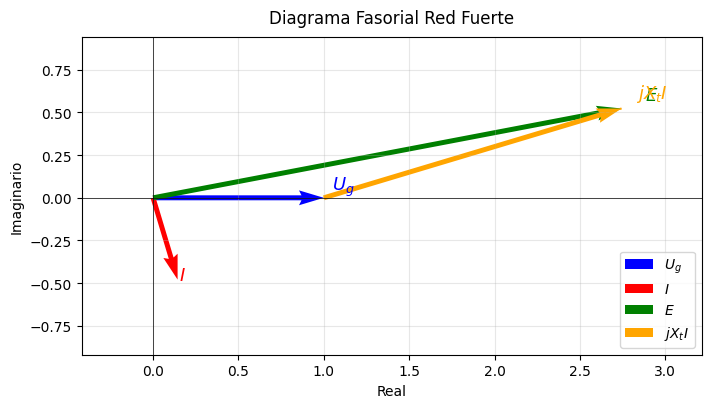

In [35]:
plot_phasor_diagram(U_g, I, phi, E, delta, X_t, title='Red Fuerte')

## Frente a una red débil

In [19]:
Z_g = 1 / RED["Débil"]["SCR"]
X_g = Z_g * (RED["Débil"]["X/R"]) / np.sqrt(1 + (RED["Débil"]["X/R"])**2)

X_t = X_inv + X_g

display("==== RED DÉBIL ====")
display(f"Z_g = {Z_g:.4f} pu")
display(f"X_g = {X_g:.4f} pu")
display(f"X_t = {X_t:.4f} pu")

I = get_current_magnitude(P_g, Q_g, U_g)
phi = get_current_angle(P_g, Q_g, U_g)
cosphi = get_power_factor(P_g, Q_g, U_g)

display(f"I = {I:.4f} pu")
display(f"phi = {phi:.4f} rad = {np.degrees(phi):.4f}°")
display(f"cosphi = {cosphi:.4f}")

E, delta = get_E_delta(U_g, X_t, I, phi)
display(f"E = {E:.4f} pu")
display(f"delta = {delta:.4f} rad = {np.degrees(delta):.4f}°")

'==== RED DÉBIL ===='

'Z_g = 0.5000 pu'

'X_g = 0.4975 pu'

'X_t = 0.6975 pu'

'I = 2.6101 pu'

'phi = 1.2793 rad = 73.3008°'

'cosphi = 0.2873'

'E = 2.7932 pu'

'delta = 0.1884 rad = 10.7946°'

(<Figure size 800x800 with 1 Axes>,
 <PolarAxes: title={'center': 'Diagrama Fasorial Red Débil'}>)

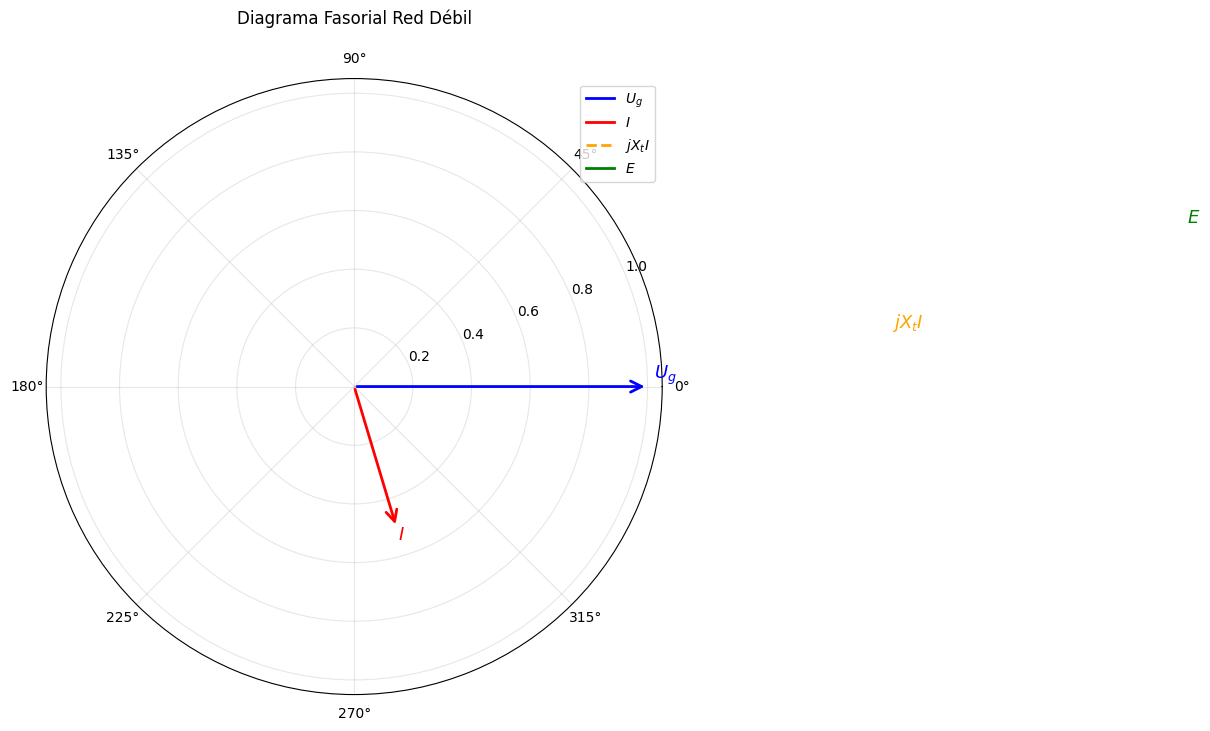

In [33]:
plot_phasor_diagram(U_g, I, phi, E, delta, X_t, title='Red Débil')